In [1]:
import numpy as np
import pandas as pd
import gc

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sksurv.metrics import concordance_index_ipcw
from sklearn.impute import SimpleImputer, KNNImputer
from sksurv.util import Surv
from lifelines import KaplanMeierFitter
from lightgbm import LGBMRegressor
import re


In [56]:


# Clinical Data
df = pd.read_csv("../clinical_train.csv")
df_eval = pd.read_csv("../clinical_test.csv")

# Molecular Data
maf_df = pd.read_csv("../molecular_train.csv")
maf_eval = pd.read_csv("../molecular_test.csv")

target_df = pd.read_csv("../target_train.csv")
#target_df_test = pd.read_csv("./target_test.csv")

# Drop rows where 'OS_YEARS' is NaN if conversion caused any issues
target_df.dropna(subset=['OS_YEARS', 'OS_STATUS'], inplace=True)


# Check the data types to ensure 'OS_STATUS' is boolean and 'OS_YEARS' is numeric
print(target_df[['OS_STATUS', 'OS_YEARS']].dtypes)

# Contarget_dfvert 'OS_YEARS' to numeric if it isn’t already
target_df['OS_YEARS'] = pd.to_numeric(target_df['OS_YEARS'], errors='coerce')

# Ensure 'OS_STATUS' is boolean
target_df['OS_STATUS'] = target_df['OS_STATUS'].astype(bool)

# Select features
features = ['BM_BLAST', 'HB', 'WBC', 'PLT']
target = ['OS_YEARS', 'OS_STATUS']

# Create the survival data format
X = df.loc[df['ID'].isin(target_df['ID']), features]
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

kmf = KaplanMeierFitter()
kmf.fit(y['OS_YEARS'], y['OS_STATUS'])
y_kaplan = kmf.survival_function_at_times(y['OS_YEARS']).values

OS_STATUS    float64
OS_YEARS     float64
dtype: object


In [57]:
from sklearn.ensemble import RandomForestRegressor

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_iter = X_train.copy()

from xgboost import XGBRegressor
# Survival-aware imputation for missing values
#imputer = IterativeImputer(estimator=LGBMRegressor(n_estimators=150,
                                                   # learning_rate=0.5,
                                                   # max_depth=5), random_state=42)
#imputer = KNNImputer(n_neighbors=5, weights='uniform')
imputer = SimpleImputer(strategy="median")
X_train[['BM_BLAST', 'HB', 'WBC', 'PLT']] = imputer.fit_transform(X_train[['BM_BLAST', 'HB','WBC', 'PLT']])
X_test[['BM_BLAST', 'HB', 'WBC', 'PLT']] = imputer.transform(X_test[['BM_BLAST', 'HB', 'WBC', 'PLT']])

kmf_train = KaplanMeierFitter()
kmf_train.fit(y_train['OS_YEARS'], y_train['OS_STATUS'])
y_surv_train = kmf_train.survival_function_at_times(y_train['OS_YEARS']).values
y_surv_val = kmf_train.survival_function_at_times(y_test['OS_YEARS']).values


## Feature engineering helper functions


In [58]:
def extract_chromosomes(karyo):
    matches = re.findall(r'(?<!\d)(\d{1,2})(?!\d)', str(karyo))  # Extract chromosome numbers (1-22, X, Y)
    return len(set(matches))  # Count unique chromosomes affected

def count_deletions(karyo):
    return len(re.findall(r'del\(\d{1,2}\)', str(karyo)))  # Count deletions

def count_translocations(karyo):
    # Matches patterns like t(3;3), t(3;X), etc.
    return len(re.findall(r't\([\dxy;]+\)', str(karyo)))  # Count translocations

def frameshift_ratio(df):
    total_mutations = df.shape[0]
    if total_mutations == 0:
        return 0
    frameshift_mutations = df[df['EFFECT'] == 'frameshift_variant'].shape[0]
    return frameshift_mutations / total_mutations

def extract_cytogenetics_info(cytogenetics):
    if pd.isna(cytogenetics):
        return 0  # Handle missing values
    # Example: Count the number of abnormalities
    abnormalities = cytogenetics.split(',')
    return len(abnormalities)

def chr_density(chromosome_number, df, df_main, chromosome_length):
    df['CHR'] = df['CHR'].astype(str).str.strip()
    df[f'is_chr{chromosome_number}'] = df['CHR'].apply(lambda x: 1 if x == chromosome_number else 0)

    new_col_name = 'chr'+chromosome_number

    chr_counts = df.groupby('ID').agg(
        **{new_col_name: (f'is_chr{chromosome_number}', 'sum')}
    ).reset_index()

    chr_counts[f'chr{chromosome_number}_mutation_density'] = chr_counts[new_col_name] / chromosome_length

    df_main = df_main.merge(chr_counts[['ID', f'chr{chromosome_number}_mutation_density']], on='ID', how='left').fillna(
        {f'chr{chromosome_number}_mutation_density': 0}
    )

    return df_main

In [59]:
tmp = maf_df.groupby('ID').size().reset_index(name='Nmut')
df_2 = df.merge(tmp, on='ID', how='left').fillna({'Nmut': 0})

# Step: Aggregate the VAF values per patient
vaf_agg = maf_df.groupby('ID')['VAF'].mean().reset_index(name='VAF_mean')
vaf_sum = maf_df.groupby('ID')['VAF'].sum().reset_index(name='VAF_sum')

# Merge the aggregated VAF values into the main dataframe
df_2 = (df_2.merge(vaf_agg, on='ID', how='left')
              .merge(vaf_sum, on='ID', how='left')
              .fillna({'VAF_mean': 0, 'VAF_sum': 0}))

# Count the number of unique genes affected per patient
unique_genes = maf_df.groupby('ID')['GENE'].nunique().reset_index(name='unique_genes')

df_2 = df_2.merge(unique_genes, on='ID', how='left').fillna({'unique_genes': 0})

genes = ['TP53', 'FLT3']
for gene in genes:
    vaf_gene = maf_df[maf_df['GENE'] == gene].groupby('ID')['VAF'].mean().reset_index(name=f'VAF_{gene}')
    df_2 = df_2.merge(vaf_gene, on='ID', how='left').fillna({f'VAF_{gene}': 0})

# Number of duplications
# This counts the occurrences of "dup(" in the CYTOGENETICS string.
df_2['num_duplications'] = df_2['CYTOGENETICS'].str.count(r'dup\(')

# Number of unique chromosomes mutated
df_2['num_unique_chromosomes'] = df_2['CYTOGENETICS'].apply(extract_chromosomes)

# Number of deleted chromosomes
df_2['num_deletions'] = df_2['CYTOGENETICS'].apply(count_deletions)

# Count translocations
df_2['num_translocations'] = df_2['CYTOGENETICS'].apply(count_translocations)

# Compute frameshift ratio per patient
frameshift_df = maf_df.groupby('ID').apply(frameshift_ratio).reset_index(name='frameshift_ratio')
df_2 = df_2.merge(frameshift_df, on='ID', how='left').fillna({'frameshift_ratio': 0})

df_2['cytogenetics_abnormalities'] = df_2['CYTOGENETICS'].apply(extract_cytogenetics_info)

# Fraction of Deletions: Proportion of deletions among all cytogenetic abnormalities
df_2['frac_deletions'] = df_2['num_deletions'] / df_2['cytogenetics_abnormalities'].replace(0, np.nan)
df_2.fillna({'frac_deletions' :0}, inplace=True)

chromosome_lengths = {'7': 159345973/1e6,
                      # '4': 191273063/1e6,
                      # '2': 242193529/1e6,
                      # '17': 84276897/1e6
                      }

for i in chromosome_lengths.keys():
    df_2 = chr_density(i, maf_df, df_2, chromosome_lengths[i])

df_2.head()

C:\Users\johnn\AppData\Local\Temp\ipykernel_128336\301885852.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  frameshift_df = maf_df.groupby('ID').apply(frameshift_ratio).reset_index(name='frameshift_ratio')


,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,Nmut,...,VAF_TP53,VAF_FLT3,num_duplications,num_unique_chromosomes,num_deletions,num_translocations,frameshift_ratio,cytogenetics_abnormalities,frac_deletions,chr7_mutation_density
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",9.0,...,0.0,0.1155,0.0,5,1,0,0.333333,4,0.25,0.000000
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx",3.0,...,0.0,0.0000,0.0,1,0,0,0.666667,2,0.00,0.000000
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",3.0,...,0.0,0.0000,0.0,6,0,1,0.000000,4,0.00,0.006276
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",11.0,...,0.0,0.0000,0.0,6,1,0,0.090909,4,0.25,0.018827
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",1.0,...,0.0,0.0000,0.0,6,0,1,1.000000,4,0.00,0.000000


                   feature       VIF
0                 BM_BLAST  1.879356
1                       HB  6.433553
2                      WBC  1.533436
3                      PLT  2.216915
4                     Nmut  4.076041
5   num_unique_chromosomes  5.095582
6           frac_deletions  3.654682
7            num_deletions  4.952112
8         num_duplications  1.029231
9                 VAF_mean  4.267769
10        frameshift_ratio  1.810425
11      num_translocations  1.458392
12   chr7_mutation_density  1.356913
13                VAF_TP53  2.032737
14                VAF_FLT3  1.036298


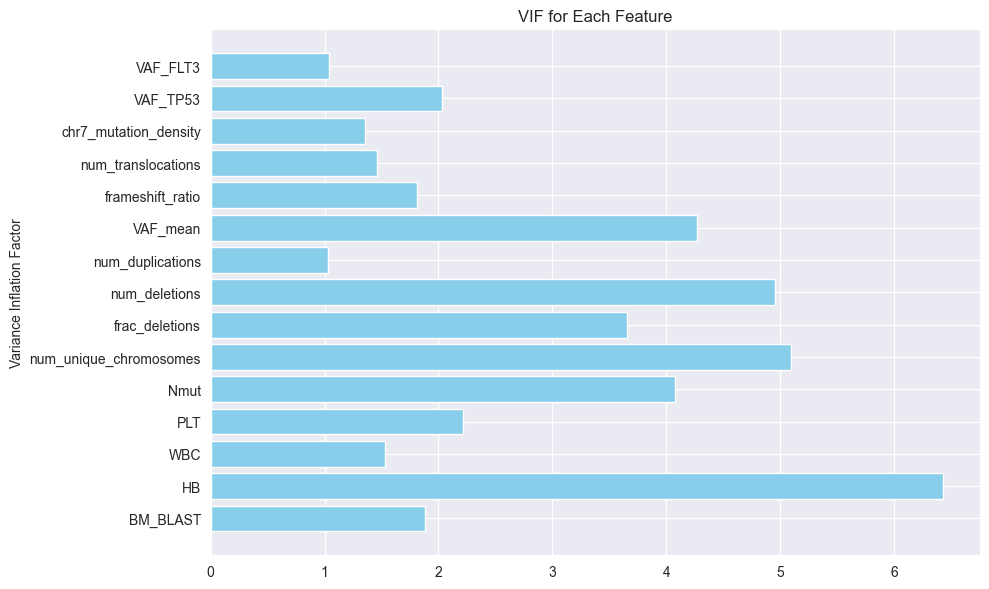

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vaf_genes = [f'VAF_{gene}' for gene in genes]
features = [ 'BM_BLAST','HB', 'WBC', 'PLT', 'Nmut', 'num_unique_chromosomes', 'frac_deletions',
            'num_deletions', 'num_duplications', 'VAF_mean', 'frameshift_ratio', 'num_translocations',
            'chr7_mutation_density']  +  vaf_genes


target = ['OS_YEARS', 'OS_STATUS']

X = df_2.loc[df_2['ID'].isin(target_df['ID']), features]
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

# Select only numeric columns from X
X_numeric = X.select_dtypes(include=[np.number])

# Replace infinite values with NaN
X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan)

# Fill missing values with the mean of each column
X_numeric_clean = X_numeric.fillna(X_numeric.mean())

# Calculate VIF for each numeric feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_numeric_clean.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric_clean.values, i)
                for i in range(X_numeric_clean.shape[1])]

# Display the VIF values
print(vif_data)

# Plot the VIF values
plt.figure(figsize=(10, 6))
plt.barh(vif_data['feature'], vif_data['VIF'], color='skyblue')

plt.ylabel("Variance Inflation Factor")
plt.title("VIF for Each Feature")
plt.tight_layout()
plt.show()

In [62]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Survival-aware imputation for missing values

#imputer = IterativeImputer(random_state=42)
#imputer = SimpleImputer(strategy="median")
X_train[features] = imputer.fit_transform(X_train[features])
X_test[features] = imputer.transform(X_test[features])


In [ ]:
from sksurv.ensemble import ExtraSurvivalTrees
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Train Extra Survival Trees model
extra_trees_42 = ExtraSurvivalTrees(n_estimators=700, max_depth=15,random_state=42, n_jobs=4)


extra_trees_42.fit(X_train, y_train)


# Make predictions
predictions = extra_trees_42.predict(X_test)

# Evaluate the model using Concordance Index IPCW
extra_trees_cindex_test = concordance_index_ipcw(y_train, y_test, predictions, tau=7)[0]


print(f"Extra Survival Trees Concordance Index IPCW on test: {extra_trees_cindex_test:.4f}")



Extra Survival Trees Concordance Index IPCW on test: 0.7107


In [ ]:
from sklearn.inspection import permutation_importance
# Feature importance for Extra Survival Trees

def perm_imp(model, X, y, n_repeats=10, random_state=42):
    est_importances_train = permutation_importance(extra_trees, X_train, y_train, n_repeats=n_repeats, random_state=42)
    perm_imps = pd.DataFrame(
        {
            k: est_importances_train[k]
            for k in (
            "importances_mean",
            "importances_std"
        )
        },
        index=X_train.columns,
    ).sort_values(by='importances_mean', ascending=False)
    print(perm_imps)

    return perm_imps

perm_imp = perm_imp(extra_trees, X_train, y_train, n_repeats=5)

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(perm_imp.index, perm_imp['importances_mean'], color='skyblue')

plt.ylabel("Extra Survival Trees Permutation Importance mean")
plt.title("Importance")
plt.tight_layout()
plt.show()

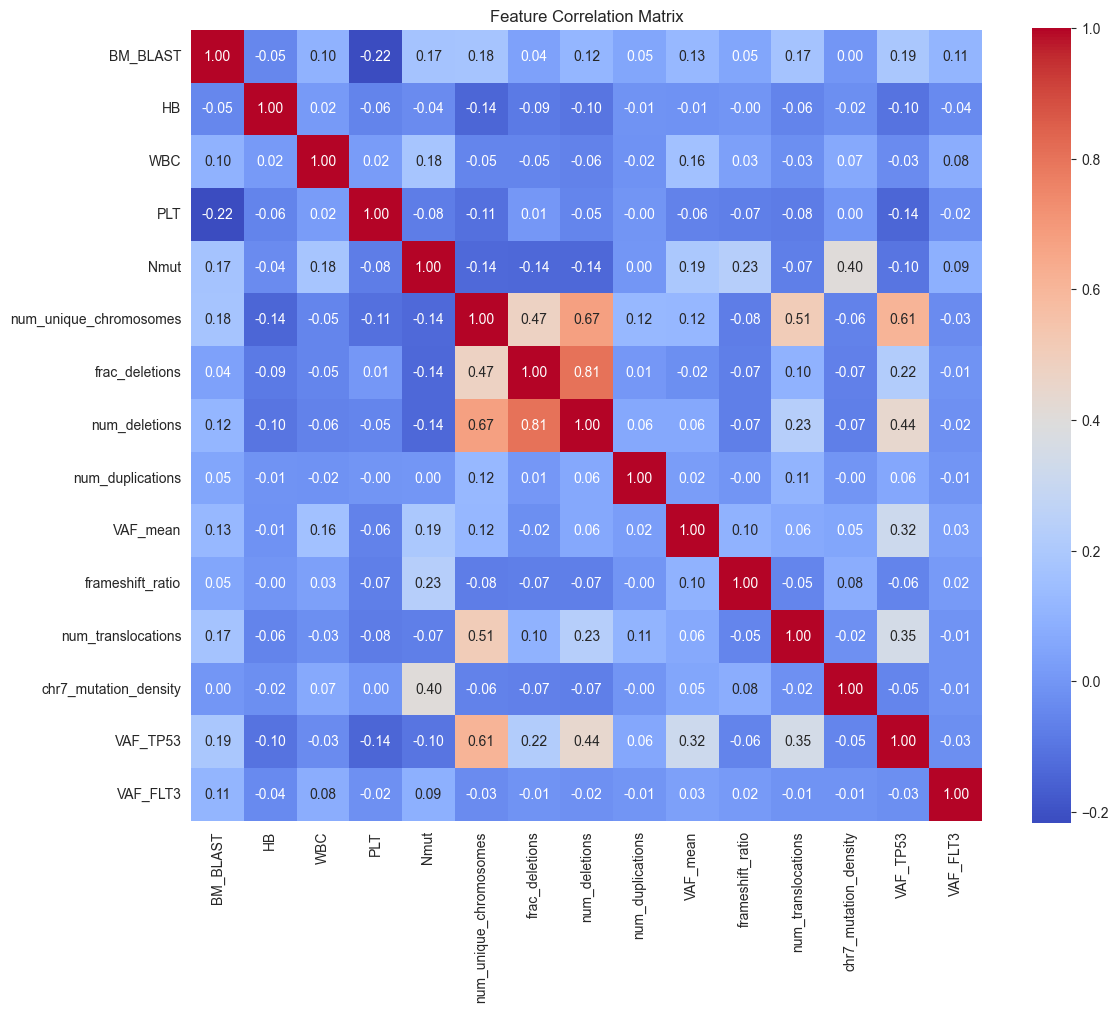

Highly correlated feature pairs (|r| > 0.8):
frac_deletions and num_deletions: correlation = 0.81


In [13]:
import seaborn as sns
# Assume X is your feature dataframe
# Select only numeric columns and handle missing/infinite values
X_numeric = X.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)
X_numeric_clean = X_numeric.fillna(X_numeric.mean())

# Compute the pairwise correlation matrix
corr_matrix = X_numeric_clean.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Identify and print highly correlated feature pairs (absolute correlation > 0.8)
high_corr_pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((cols[i], cols[j], corr_matrix.iloc[i, j]))

print("Highly correlated feature pairs (|r| > 0.8):")
for pair in high_corr_pairs:
    print(f"{pair[0]} and {pair[1]}: correlation = {pair[2]:.2f}")

In [ ]:
# FINAL MODEL
extra_trees = ExtraSurvivalTrees(n_estimators=400, max_depth=14,random_state=42, n_jobs=-1)
extra_trees.fit(X_train, y_train)

# Make predictions
predictions = extra_trees.predict(X_test)

# Evaluate the model using Concordance Index IPCW
extra_trees_cindex_test = concordance_index_ipcw(y_train, y_test, predictions, tau=7)[0]
print(f"Extra Survival Trees Concordance Index IPCW on test: {extra_trees_cindex_test:.4f}")

In [ ]:
from sklearn.model_selection import KFold

def cv_train(model, X_df, y_df):
    scores = []
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold = 0
    for train, val in kf.split(X_df, y_df):
        fold += 1
        X_train_fold, X_val_fold = X_df.iloc[train], X_df.iloc[val]
        y_train_fold, y_val_fold = y_df[train], y_df[val]

        model.fit(X_train_fold, y_train_fold)
        preds = model.predict(X_val_fold)

        score = concordance_index_ipcw(y_train_fold, y_val_fold, preds, tau=7)[0]

        scores.append(score)
        print(f"Fold {fold}: {score:.4f}")
    return scores

est_scores = cv_train(extra_trees, X_train, y_train)

In [65]:
X_full = X.copy()
X_full.loc[:, features] = imputer.fit_transform(X.loc[:, features])

In [ ]:
extra_trees_42.fit(X_full, y)


ExtraSurvivalTrees(max_depth=15, n_estimators=700, n_jobs=4, random_state=42)

In [ ]:
df_eval = pd.read_csv("../clinical_test.csv")

tmp_eval = maf_eval.groupby('ID').size().reset_index(name='Nmut')

# Merge with the training dataset and replace missing values in 'Nmut' with 0
df_eval = df_eval.merge(tmp_eval, on='ID', how='left').fillna({'Nmut': 0})

# Step: Aggregate the VAF values per patient
vaf_agg = maf_eval.groupby('ID')['VAF'].sum().reset_index(name='VAF_mean')
#vaf_sum = maf_eval.groupby('ID')['VAF'].sum().reset_index(name='VAF_sum')

# Merge the aggregated VAF values into the main dataframe
df_eval = df_eval.merge(vaf_agg, on='ID', how='left').fillna({'VAF_mean': 0})
#df_eval = df_eval.merge(vaf_sum, on='ID', how='left').fillna({'VAF_sum': 0})

# Count the number of unique genes affected per patient
unique_genes = maf_eval.groupby('ID')['GENE'].nunique().reset_index(name='unique_genes')


df_eval = df_eval.merge(unique_genes, on='ID', how='left').fillna({'unique_genes': 0})

genes = ['TP53', 'FLT3']
for gene in genes:
    vaf_gene_eval = maf_eval[maf_eval['GENE'] == gene].groupby('ID')['VAF'].mean().reset_index(name=f'VAF_{gene}')
    df_eval = df_eval.merge(vaf_gene_eval, on='ID', how='left').fillna({f'VAF_{gene}': 0})


df_eval['num_unique_chromosomes'] = df_eval['CYTOGENETICS'].apply(extract_chromosomes)

df_eval['num_deletions'] = df_eval['CYTOGENETICS'].apply(count_deletions)

# Apply the function to create a new feature
df_eval['cytogenetics_abnormalities'] = df_eval['CYTOGENETICS'].apply(extract_cytogenetics_info)

df_eval['num_duplications'] = df_eval['CYTOGENETICS'].str.count(r'dup\(')

df_eval['frac_deletions'] = df_eval['num_deletions'] / df_eval['cytogenetics_abnormalities'].replace(0, np.nan)
df_eval.fillna({'frac_deletions': 0}, inplace=True)

frameshift_df = maf_df.groupby('ID').apply(frameshift_ratio).reset_index(name='frameshift_ratio')
df_eval = df_eval.merge(frameshift_df, on='ID', how='left').fillna({'frameshift_ratio': 0})
df_eval['num_translocations'] = df_eval['CYTOGENETICS'].apply(count_translocations)

for i in chromosome_lengths.keys():
    df_eval = chr_density(i, maf_eval, df_eval, chromosome_lengths[i])

C:\Users\johnn\AppData\Local\Temp\ipykernel_128336\235905457.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  frameshift_df = maf_df.groupby('ID').apply(frameshift_ratio).reset_index(name='frameshift_ratio')


In [ ]:
df_eval[features] = imputer.transform(df_eval[features])
prediction_on_test_set = extra_trees_42.predict(df_eval.loc[:, features])



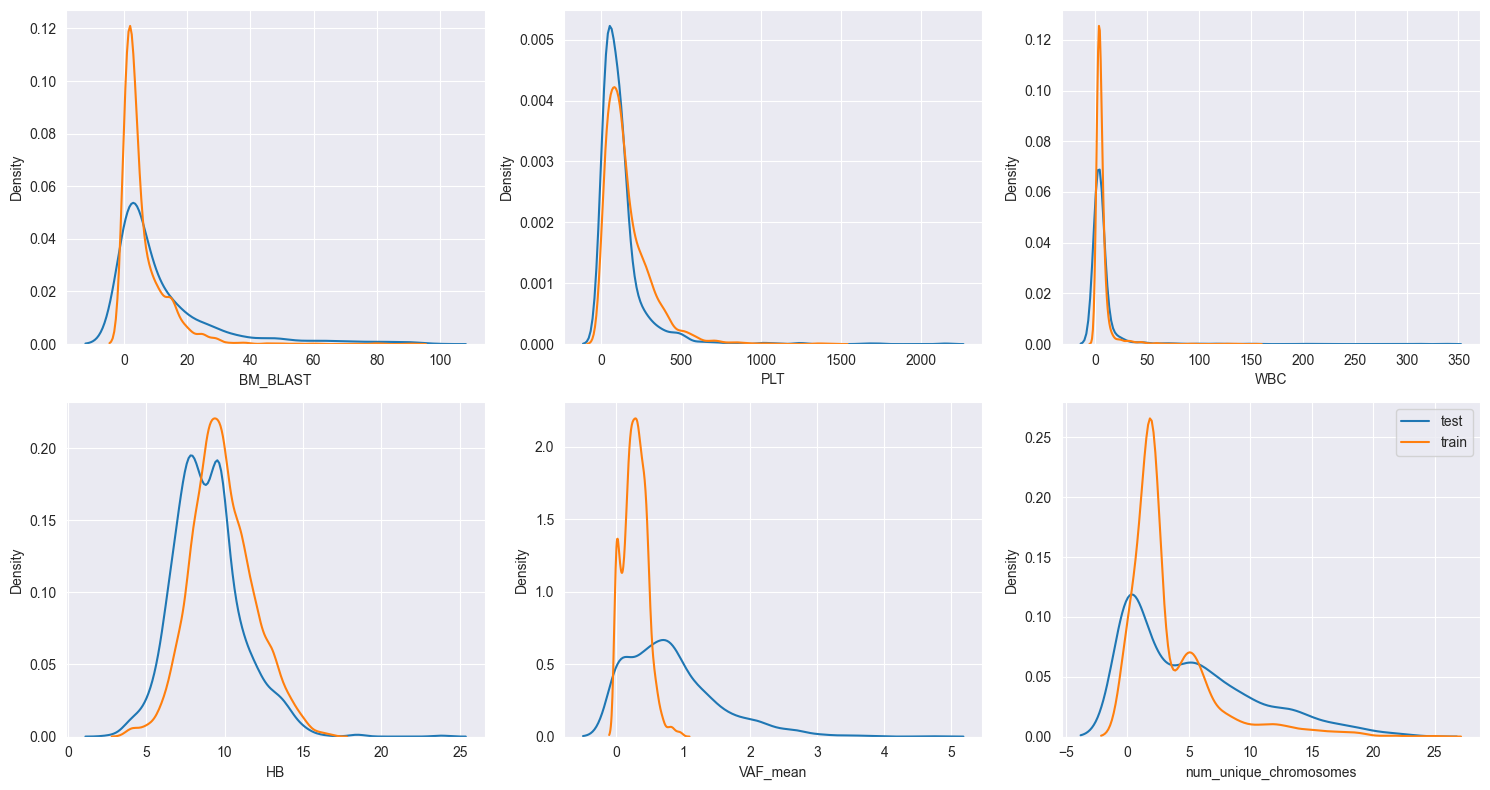

In [68]:
av_features = ['PLT', 'WBC', 'VAF_mean', 'HB', 'BM_BLAST', 'num_unique_chromosomes']

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
sns.kdeplot(ax=ax[0][0], data=df_eval['BM_BLAST'], label='test')
sns.kdeplot(ax=ax[0][0], data=X_full['BM_BLAST'], label='train')

sns.kdeplot(ax=ax[0][1], data=df_eval['PLT'], label='test')
sns.kdeplot(ax=ax[0][1], data=X_full['PLT'], label='train')

sns.kdeplot(ax=ax[0][2], data=df_eval['WBC'], label='test')
sns.kdeplot(ax=ax[0][2], data=X_full['WBC'], label='train')

sns.kdeplot(ax=ax[1][0], data=df_eval['HB'], label='test')
sns.kdeplot(ax=ax[1][0], data=X_full['HB'], label='train')

sns.kdeplot(ax=ax[1][1], data=df_eval['VAF_mean'], label='test')
sns.kdeplot(ax=ax[1][1], data=X_full['VAF_mean'], label='train')

sns.kdeplot(ax=ax[1][2], data=df_eval['num_unique_chromosomes'], label='test')
sns.kdeplot(ax=ax[1][2], data=X_full['num_unique_chromosomes'], label='train')



plt.legend()
plt.tight_layout()

In [69]:
from sklearn.preprocessing import QuantileTransformer

In [77]:
X_fullq = X.copy()
df_evalq = df_eval.copy()
X_fullq.loc[:, features] = imputer.fit_transform(X_fullq.loc[:, features])

qtrans = QuantileTransformer(n_quantiles=1000, output_distribution='normal')

X_fullq.loc[:, features] = qtrans.fit_transform(X_fullq.loc[:, features])
df_evalq.loc[:, features] = qtrans.transform(df_evalq.loc[:, features])

C:\Users\johnn\AppData\Local\Temp\ipykernel_128336\2218795781.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.74967004 -0.90708024  1.01457112 ...  1.51358893  1.43197089
 -0.11567779]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_fullq.loc[:, features] = qtrans.fit_transform(X_fullq.loc[:, features])
C:\Users\johnn\AppData\Local\Temp\ipykernel_128336\2218795781.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.19976601 -5.19933758 -5.19933758 ...  1.19976601  1.19976601
 -5.19933758]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_fullq.loc[:, features] = qtrans.fit_transform(X_fullq.loc[:, features])
C:\Users\johnn\AppData\Local\Temp\ipykernel_128336\2218795781.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and wil

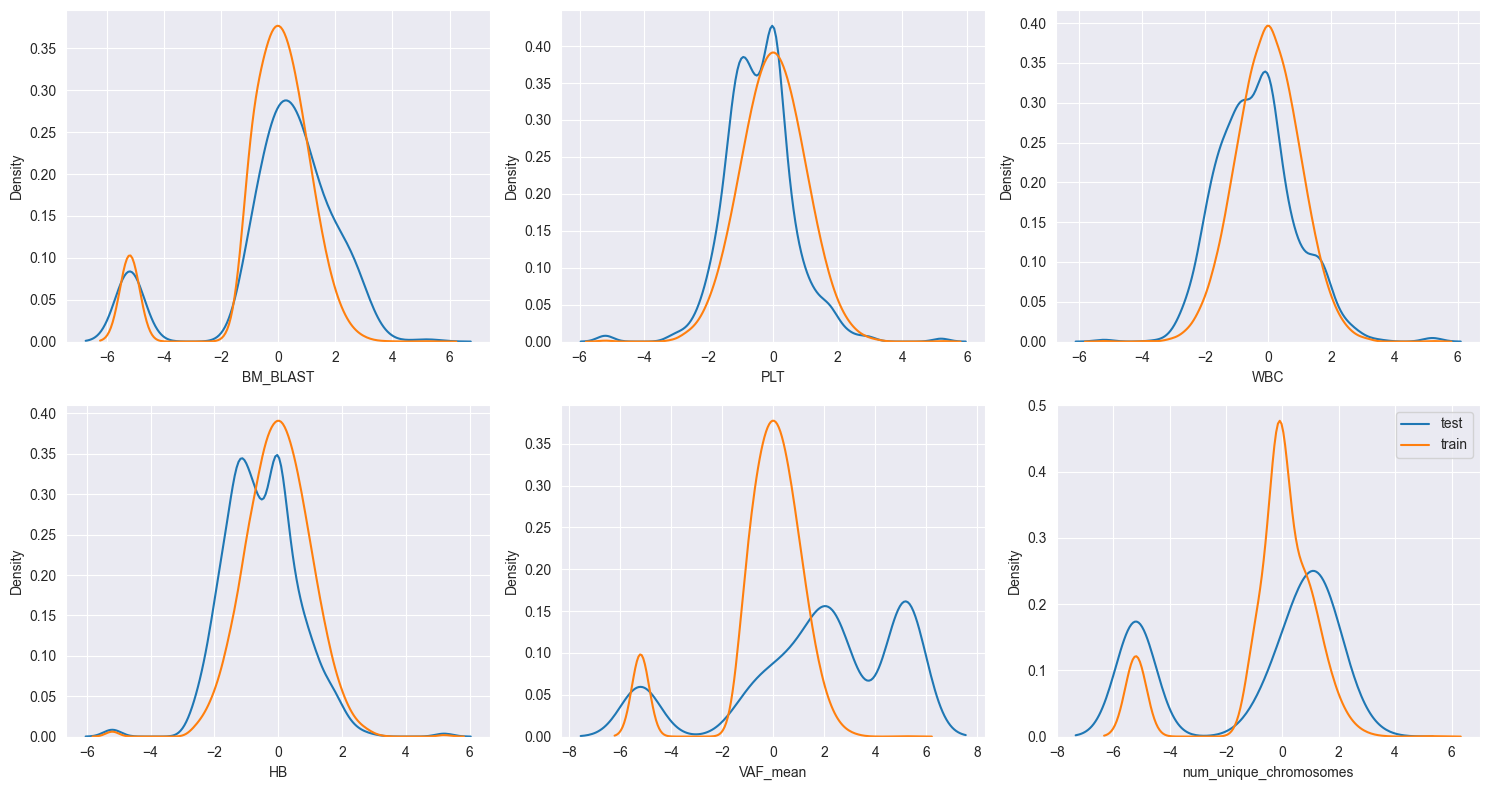

In [78]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
sns.kdeplot(ax=ax[0][0], data=df_evalq['BM_BLAST'], label='test')
sns.kdeplot(ax=ax[0][0], data=X_fullq['BM_BLAST'], label='train')

sns.kdeplot(ax=ax[0][1], data=df_evalq['PLT'], label='test')
sns.kdeplot(ax=ax[0][1], data=X_fullq['PLT'], label='train')

sns.kdeplot(ax=ax[0][2], data=df_evalq['WBC'], label='test')
sns.kdeplot(ax=ax[0][2], data=X_fullq['WBC'], label='train')

sns.kdeplot(ax=ax[1][0], data=df_evalq['HB'], label='test')
sns.kdeplot(ax=ax[1][0], data=X_fullq['HB'], label='train')

sns.kdeplot(ax=ax[1][1], data=df_evalq['VAF_mean'], label='test')
sns.kdeplot(ax=ax[1][1], data=X_fullq['VAF_mean'], label='train')

sns.kdeplot(ax=ax[1][2], data=df_evalq['num_unique_chromosomes'], label='test')
sns.kdeplot(ax=ax[1][2], data=X_fullq['num_unique_chromosomes'], label='train')



plt.legend()
plt.tight_layout()

In [50]:
df_eval['risk_score'] = prediction_on_test_set# + prediction_on_test_set_1 + prediction_on_test_set_5 + prediction_on_test_set_10 + prediction_on_test_set_8)/5 # Invert OS_YEARS to compute risk scores

# Create the final submission DataFrame
submission = df_eval[['ID', 'risk_score']].copy()

# Save to CSV
filename = 'EST_18_SEED_ENSEMBLE'
submission.to_csv(f'./submissions/{filename}.csv', index=False)

print("Submission file has been created.")

Submission file has been created.


In [51]:
submission

,ID,risk_score
0,KYW1,952.500296
1,KYW2,894.963900
2,KYW3,409.200050
3,KYW4,863.307823
4,KYW5,882.571184
...,...,...
1188,KYW1189,383.496156
1189,KYW1190,441.616702
1190,KYW1191,522.845250
1191,KYW1192,476.456911


In [52]:
extra_trees_42.get_params(), features

({'bootstrap': True,
  'low_memory': False,
  'max_depth': 15,
  'max_features': 'sqrt',
  'max_leaf_nodes': None,
  'max_samples': None,
  'min_samples_leaf': 3,
  'min_samples_split': 6,
  'min_weight_fraction_leaf': 0.0,
  'n_estimators': 700,
  'n_jobs': 4,
  'oob_score': False,
  'random_state': 42,
  'verbose': 0,
  'warm_start': False},
 ['BM_BLAST',
  'HB',
  'WBC',
  'PLT',
  'Nmut',
  'num_unique_chromosomes',
  'frac_deletions',
  'num_deletions',
  'num_duplications',
  'VAF_mean',
  'frameshift_ratio',
  'num_translocations',
  'chr7_mutation_density',
  'VAF_TP53',
  'VAF_FLT3'])

In [53]:
model_params = dict(extra_trees.get_params())
model_params
with open(f'./submissions/{filename}.txt', 'w') as file:
    for item in features:
        file.write(item + '\n')
    for item, value in model_params.items():
        file.write(f'{item}={value}\n')
